# Phase 02 — Exploratory Data Analysis

## 1. Objective

This notebook performs exploratory data analysis on the original Credit Risk
dataset used as the source dataset for the MLOps Engineering Roadmap.

The objective is to understand the structure, quality, distributions, and
relationships within the source data before designing the preprocessing and
ML data preparation pipeline.

The original dataset will remain unchanged throughout the analysis.

---

## 2. Business Context

The dataset represents a credit risk / loan approval problem.

The source dataset contains customer information, financial history,
loan application information, and the target variable used for credit-risk
prediction.

The dataset will later be organized into separate business domains and
used to demonstrate AWS data engineering and MLOps workflows.

---

## 3. Source Dataset

**Source file:**

`data/raw/original/credit_risk_dataset.csv`

The original dataset represents the source-of-truth data for this project.

---

## 4. EDA Methodology

The analysis will cover:

1. Dataset structure
2. Data types
3. Missing values
4. Duplicate records
5. Numerical variables
6. Categorical variables
7. Target variable
8. Variable relationships
9. Potential outliers and suspicious values
10. Data-quality observations
11. Preprocessing requirements

---

## 8. Categorical Variable Analysis

## 9. Target Variable Analysis

## 10. Relationship Analysis

## 11. Potential Outliers and Anomalies

## 12. EDA Findings

## 13. Preprocessing Requirements

## 14. Conclusions

In [9]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "original" / "credit_risk_dataset.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 5. Dataset Structure

In [ ]:
## 5. Dataset Structure

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
for column in df.columns:
    print(f"- {column}")

Dataset shape:
(32581, 12)

Column names:
- person_age
- person_income
- person_home_ownership
- person_emp_length
- loan_intent
- loan_grade
- loan_amnt
- loan_int_rate
- loan_status
- loan_percent_income
- cb_person_default_on_file
- cb_person_cred_hist_length


## 6. Data Quality Analysis
### 6.1 Missing Values

In [5]:
## 6. Data Quality Analysis

### 6.1 Missing Values

missing_values = df.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percentage"] = missing_summary["missing_count"] / len(df) * 100

missing_summary

,missing_count,missing_percentage
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000


### 6.2 Duplicate Records

In [ ]:
### 6.2 Duplicate Records

duplicate_count = df.duplicated().sum()

print(f"Duplicate records: {duplicate_count}")

Duplicate records: 165


### 6.3 Data Types

In [10]:
### 6.3 Data Types

dtype_summary = df.dtypes.rename("data_type").to_frame()

dtype_summary

,data_type
person_age,int64
person_income,int64
person_home_ownership,str
person_emp_length,float64
loan_intent,str
loan_grade,str
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [8]:
## 7. Numerical Variable Analysis
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

## 7. Numerical Variable Analysis
### 7.1 Numerical Variable Identification

In [12]:
### 7.1 Numerical Variable Identification
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

### 7.2 Numerical Variable Summary

In [13]:
### 7.2 Numerical Variable Summary
numerical_summary = df[numerical_columns].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


### 7.3 Numerical Variable Distributions

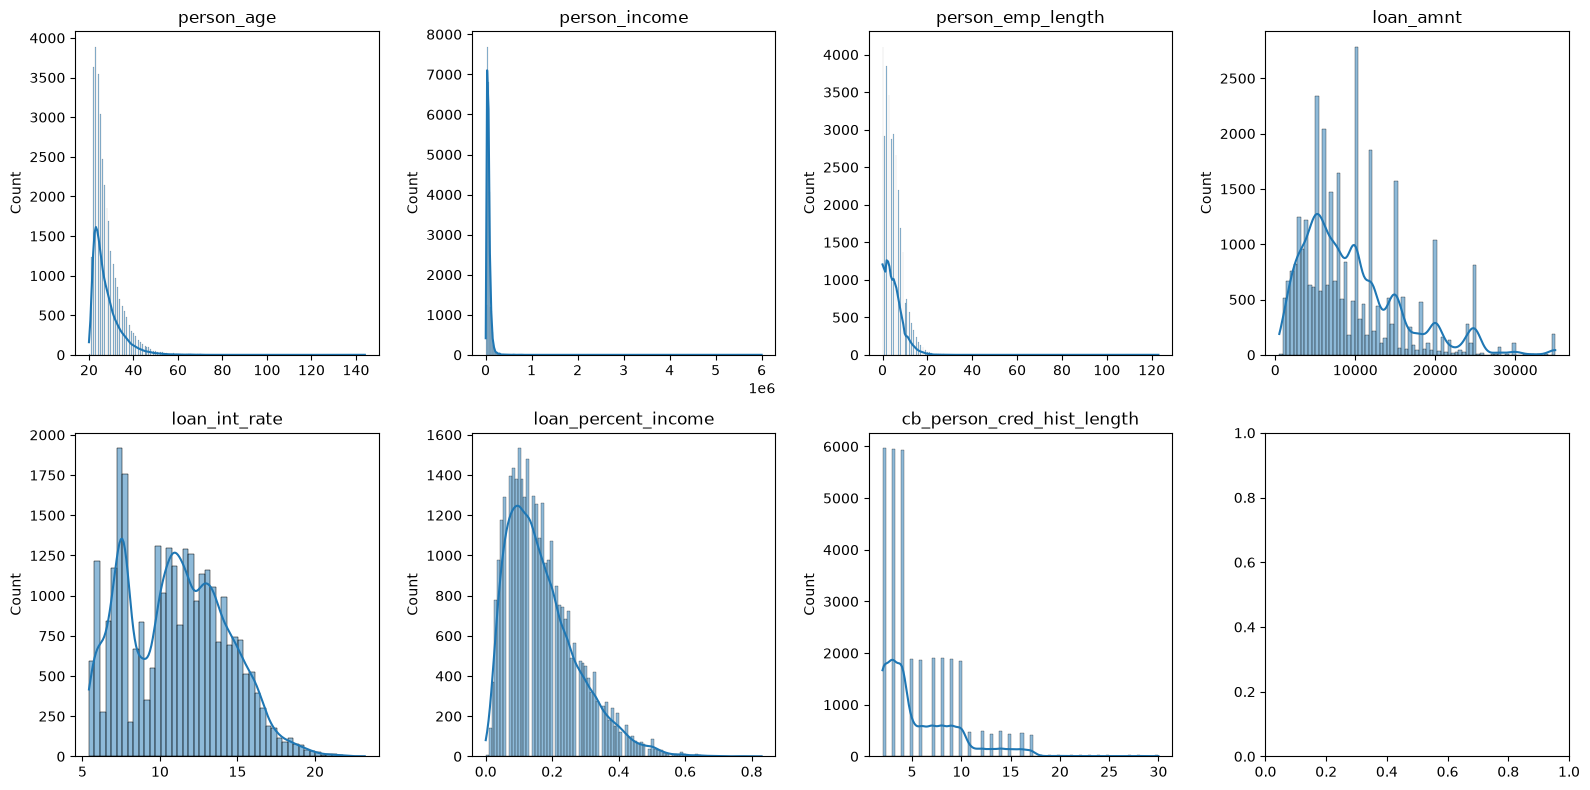

In [16]:
### 7.3 Numerical Variable Distributions
import matplotlib.pyplot as plt
import seaborn as sns

continuous_columns = [column for column in numerical_columns if column != "loan_status"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(16, 8),
)

for ax, column in zip(axes.flat, continuous_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=ax,
    )
    ax.set_title(column)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 8. Categorical Variable Analysis
### 8.1 Categorical Variable Identification

In [17]:
## 8. Categorical Variable Analysis
### 8.1 Categorical Variable Identification
categorical_columns = df.select_dtypes(include=["object", "str", "category"]).columns.tolist()

categorical_columns

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

### 8.2 Categorical Variable Frequencies

In [18]:
### 8.2 Categorical Variable Frequencies
categorical_frequencies = {
    column: df[column].value_counts(dropna=False) for column in categorical_columns
}

categorical_frequencies

{'person_home_ownership': person_home_ownership
 RENT        16446
 MORTGAGE    13444
 OWN          2584
 OTHER         107
 Name: count, dtype: int64,
 'loan_intent': loan_intent
 EDUCATION            6453
 MEDICAL              6071
 VENTURE              5719
 PERSONAL             5521
 DEBTCONSOLIDATION    5212
 HOMEIMPROVEMENT      3605
 Name: count, dtype: int64,
 'loan_grade': loan_grade
 A    10777
 B    10451
 C     6458
 D     3626
 E      964
 F      241
 G       64
 Name: count, dtype: int64,
 'cb_person_default_on_file': cb_person_default_on_file
 N    26836
 Y     5745
 Name: count, dtype: int64}

### 8.3 Categorical Variable Distributions

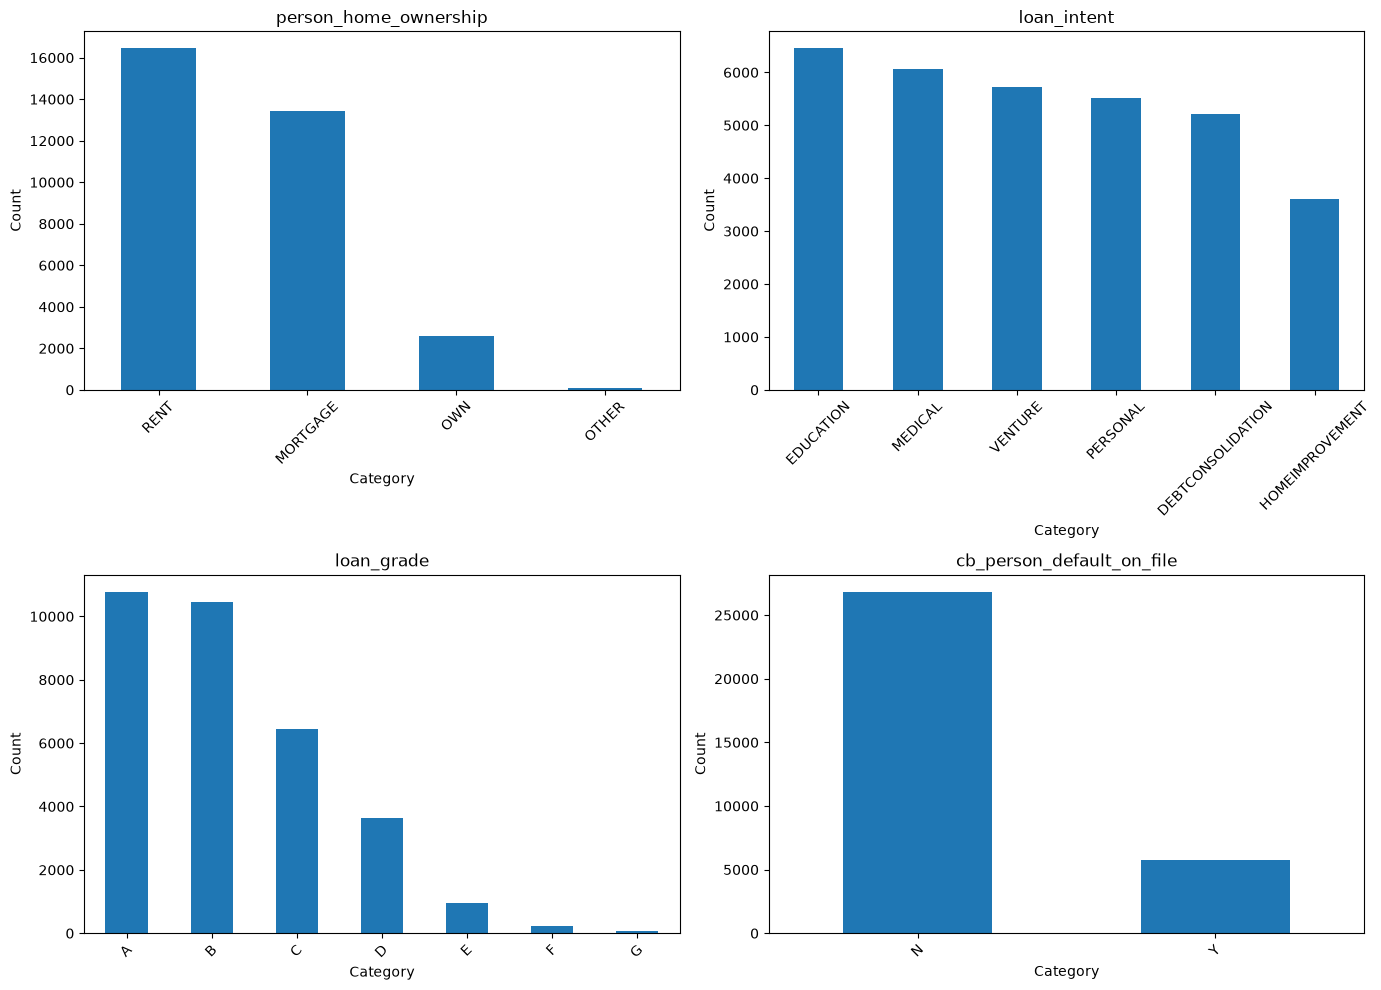

In [19]:
### 8.3 Categorical Variable Distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
)

for ax, column in zip(axes.flatten(), categorical_columns):
    value_counts = df[column].value_counts()

    value_counts.plot(
        kind="bar",
        ax=ax,
    )

    ax.set_title(column)
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 8.4 Target Variable Distribution

In [20]:
### 8.4 Target Variable Distribution
target_distribution = df["loan_status"].value_counts(dropna=False)

target_distribution

loan_status
0    25473
1     7108
Name: count, dtype: int64

### 8.5 Target Variable Distribution

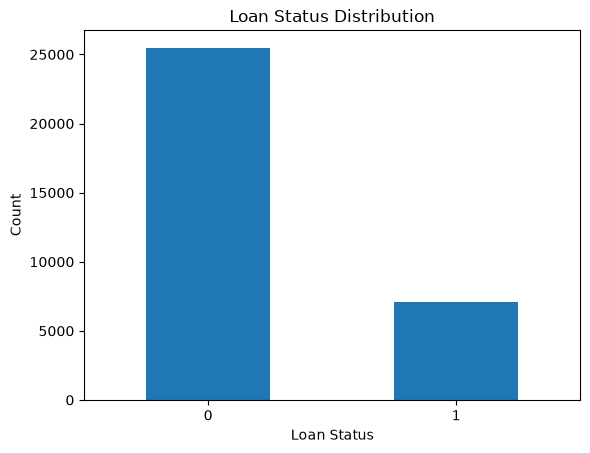

In [21]:
### 8.5 Target Variable Distribution
df["loan_status"].value_counts().plot(
    kind="bar",
    title="Loan Status Distribution",
)

plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

## 9. Feature vs. Target Analysis

### 9.1 Numerical Features vs. Target

In [22]:
## 9. Feature vs. Target Analysis

### 9.1 Numerical Features vs. Target
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_feature_columns = [column for column in numerical_columns if column != "loan_status"]

numerical_feature_columns

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']

### 9.2 Numerical Features by Loan Status

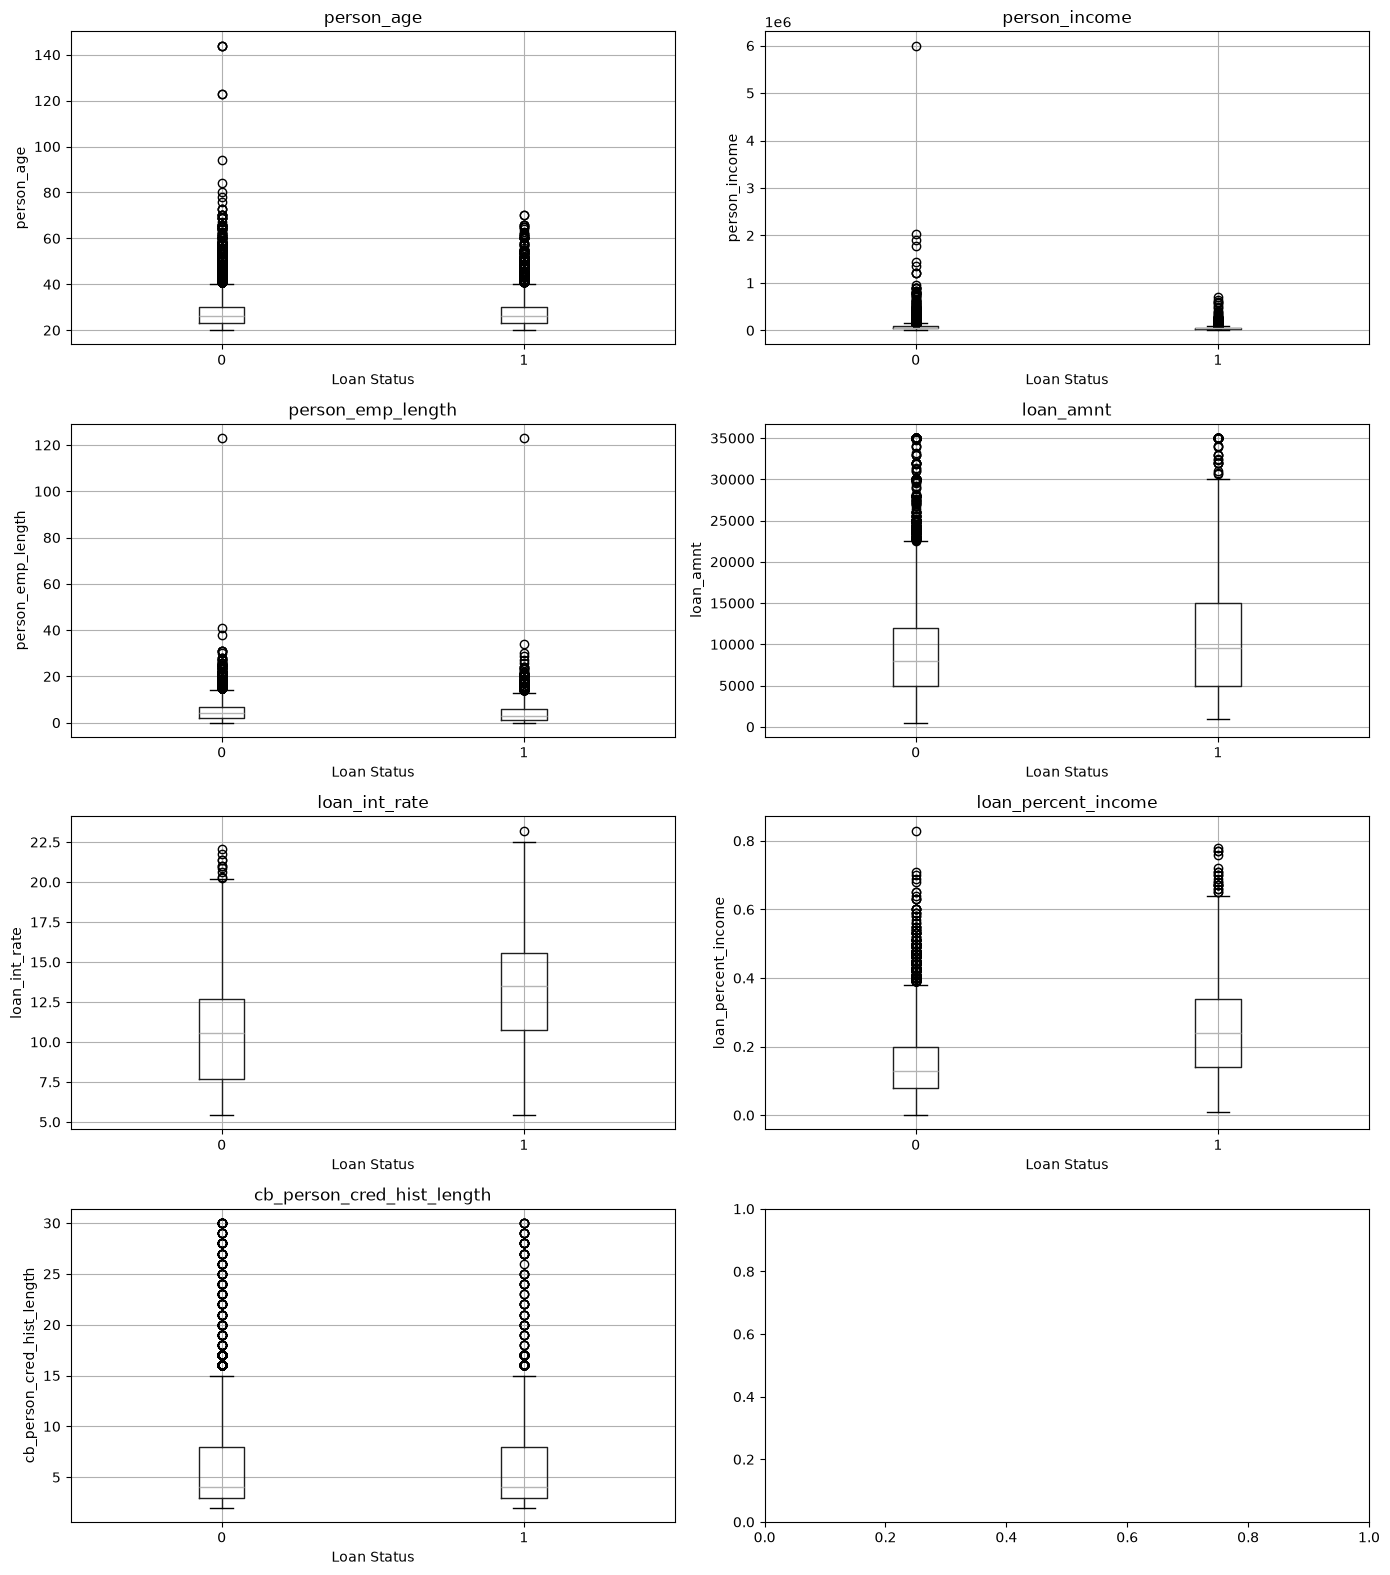

In [23]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16),
)

for ax, column in zip(axes.flat, numerical_feature_columns):
    df.boxplot(
        column=column,
        by="loan_status",
        ax=ax,
    )
    ax.set_title(column)
    ax.set_xlabel("Loan Status")
    ax.set_ylabel(column)

plt.suptitle("")
plt.tight_layout()
plt.show()

### 9.3 Categorical Features vs. Loan Status

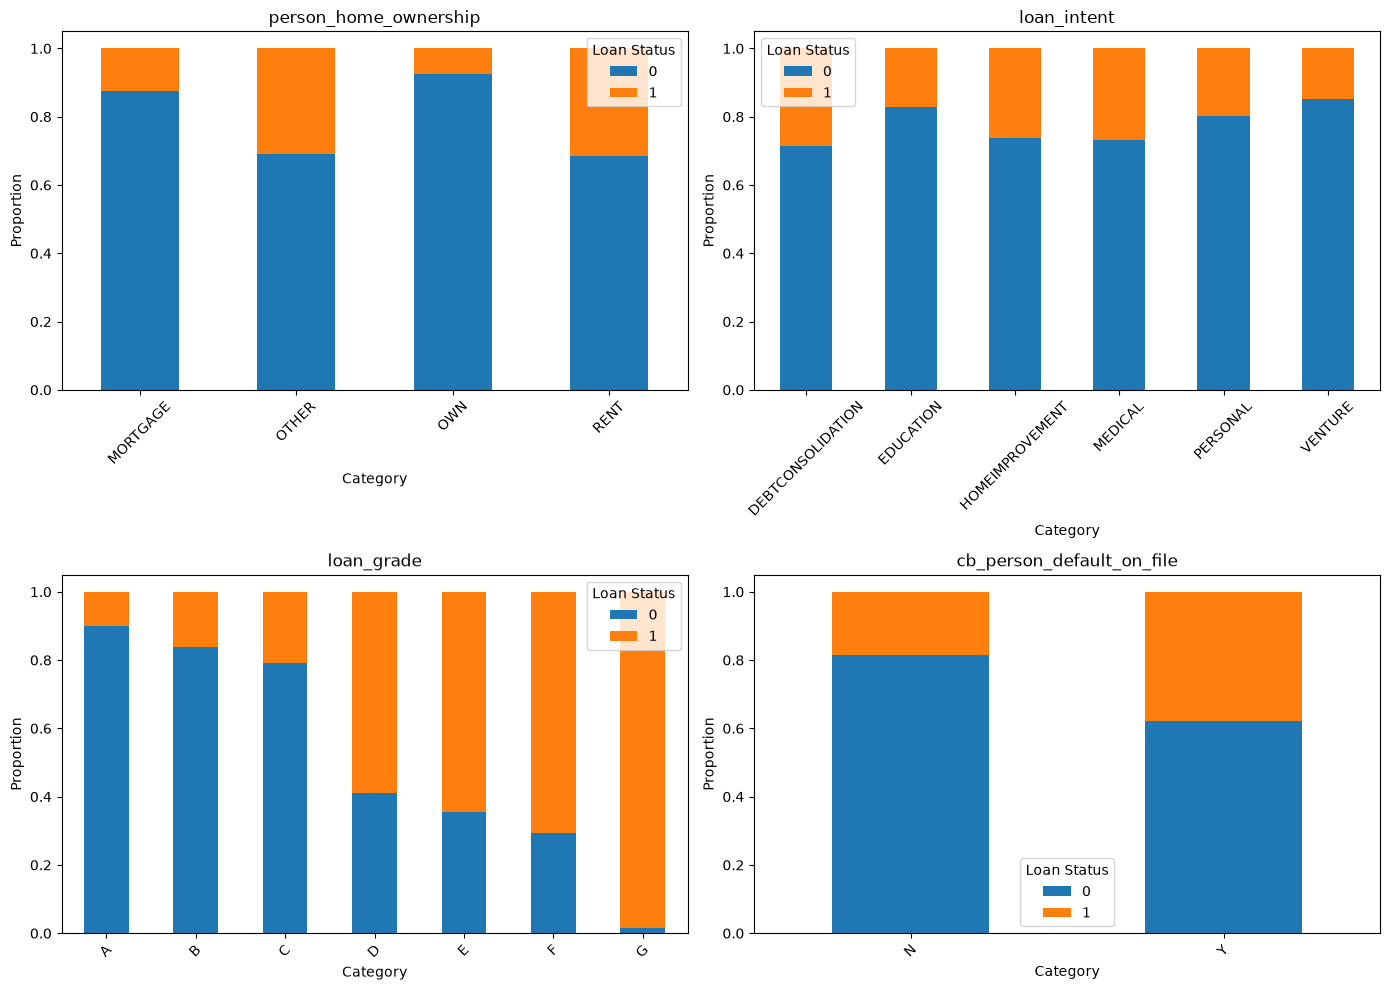

In [24]:
### 9.3 Categorical Features vs. Loan Status
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
)

for ax, column in zip(axes.flatten(), categorical_columns):
    pd.crosstab(
        df[column],
        df["loan_status"],
        normalize="index",
    ).plot(
        kind="bar",
        stacked=True,
        ax=ax,
    )

    ax.set_title(column)
    ax.set_xlabel("Category")
    ax.set_ylabel("Proportion")
    ax.legend(
        title="Loan Status",
        labels=["0", "1"],
    )
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Data Quality Investigation

### 10.1 Person Age Validation

In [25]:
## 10. Data Quality Investigation

### 10.1 Person Age Validation
df.loc[
    df["person_age"] > 100,
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_status",
    ],
].sort_values("person_age")

,person_age,person_income,person_emp_length,loan_status
747,123,78000,7.0,0
575,123,80004,2.0,0
183,144,200000,4.0,0
81,144,250000,4.0,0
32297,144,6000000,12.0,0


### 10.2 Employment Length Validation

In [26]:
### 10.2 Employment Length Validation
df.loc[
    df["person_emp_length"] > 50,
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_status",
    ],
].sort_values("person_emp_length")

,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
210,21,123.0,192000,0


### 10.3 Income Validation

In [27]:
df.loc[
    df["person_income"] > 1000000,
    [
        "person_age",
        "person_income",
        "person_emp_length",
        "loan_amnt",
        "loan_status",
    ],
].sort_values("person_income")

,person_age,person_income,person_emp_length,loan_amnt,loan_status
17833,32,1200000,1.0,12000,0
29119,36,1200000,16.0,10000,0
29120,40,1200000,1.0,10000,0
31922,47,1362000,9.0,6600,0
31924,44,1440000,7.0,6400,0
32497,63,1782000,13.0,12025,0
32546,60,1900000,5.0,1500,0
30049,42,2039784,0.0,8450,0
32297,144,6000000,12.0,5000,0


### 10.4 Categorical Value Validation

In [28]:
### 10.4 Categorical Value Validation
expected_categories = {
    "person_home_ownership": {
        "RENT",
        "MORTGAGE",
        "OWN",
        "OTHER",
    },
    "loan_intent": {
        "EDUCATION",
        "MEDICAL",
        "VENTURE",
        "PERSONAL",
        "DEBTCONSOLIDATION",
        "HOMEIMPROVEMENT",
    },
    "loan_grade": {
        "A",
        "B",
        "C",
        "D",
        "E",
        "F",
        "G",
    },
    "cb_person_default_on_file": {
        "Y",
        "N",
    },
}

for column, expected in expected_categories.items():
    actual = set(df[column].dropna().unique())

    print(f"\n{column}")
    print(f"Unexpected categories: {actual - expected}")
    print(f"Missing expected categories: {expected - actual}")


person_home_ownership
Unexpected categories: set()
Missing expected categories: set()

loan_intent
Unexpected categories: set()
Missing expected categories: set()

loan_grade
Unexpected categories: set()
Missing expected categories: set()

cb_person_default_on_file
Unexpected categories: set()
Missing expected categories: set()


### 10.5 Target Validation

In [29]:
### 10.5 Target Validation
expected_target_values = {0, 1}

actual_target_values = set(df["loan_status"].dropna().unique())

print("Unexpected target values:")
print(actual_target_values - expected_target_values)

print("\nMissing expected target values:")
print(expected_target_values - actual_target_values)

Unexpected target values:
set()

Missing expected target values:
set()


### 10.6 Age–Employment Consistency

In [30]:
### 10.6 Age–Employment Consistency
inconsistent_employment = df.loc[
    df["person_emp_length"] > df["person_age"],
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_status",
    ],
].sort_values(
    "person_emp_length",
    ascending=False,
)

print(inconsistent_employment)

     person_age  person_emp_length  person_income  loan_status
0            22              123.0          59000            1
210          21              123.0         192000            0


### 10.7 — Credit-history consistency

In [31]:
### 10.7 — Credit-history consistency
inconsistent_credit_history = df.loc[
    df["cb_person_cred_hist_length"] >= df["person_age"],
    [
        "person_age",
        "cb_person_cred_hist_length",
        "person_income",
        "loan_status",
    ],
].sort_values(
    "cb_person_cred_hist_length",
    ascending=False,
)

print(inconsistent_credit_history)

Empty DataFrame
Columns: [person_age, cb_person_cred_hist_length, person_income, loan_status]
Index: []


### 10.8 — Loan-to-income consistency

In [32]:
### 10.8 — Loan-to-income consistency
loan_income_consistency = df.loc[
    df["person_income"] > 0,
    [
        "person_income",
        "loan_amnt",
        "loan_percent_income",
    ],
].copy()

loan_income_consistency["calculated_ratio"] = (
    loan_income_consistency["loan_amnt"] / loan_income_consistency["person_income"]
)

loan_income_consistency["ratio_difference"] = (
    loan_income_consistency["loan_percent_income"] - loan_income_consistency["calculated_ratio"]
)

print(loan_income_consistency["ratio_difference"].describe())

count    32581.000000
mean        -0.000350
std          0.004926
min         -0.093382
25%         -0.002500
50%          0.000000
75%          0.002500
max          0.005000
Name: ratio_difference, dtype: float64


In [33]:
# 10.9 — Identify inconsistent loan-to-income records
inconsistent_loan_income = loan_income_consistency.loc[
    loan_income_consistency["ratio_difference"].abs() > 0.01
].sort_values(
    "ratio_difference",
)

print(inconsistent_loan_income)

       person_income  loan_amnt  loan_percent_income  calculated_ratio  \
4              54400      35000                 0.55          0.643382   
11873          60350      35000                 0.49          0.579950   
11253          56403      30000                 0.45          0.531887   
13005          63750      35000                 0.47          0.549020   
24150          54400      27050                 0.42          0.497243   
...              ...        ...                  ...               ...   
5567           55488       5000                 0.08          0.090110   
15126          94102       8475                 0.08          0.090062   
255           142800      10000                 0.06          0.070028   
28102          71400       5000                 0.06          0.070028   
26735          83300       5000                 0.05          0.060024   

       ratio_difference  
4             -0.093382  
11873         -0.089950  
11253         -0.081887  
13005  

In [34]:
## 10.10 — Investigate the suspicious records
suspicious_loan_income = df.loc[
    loan_income_consistency["ratio_difference"].abs() > 0.01,
    [
        "person_age",
        "person_income",
        "person_home_ownership",
        "person_emp_length",
        "loan_intent",
        "loan_grade",
        "loan_amnt",
        "loan_int_rate",
        "loan_status",
        "loan_percent_income",
        "cb_person_default_on_file",
        "cb_person_cred_hist_length",
    ],
]

print(suspicious_loan_income.head(20))

     person_age  person_income person_home_ownership  person_emp_length  \
4            24          54400                  RENT                8.0   
17           23          92111                  RENT                7.0   
40           26          62050                  RENT                6.0   
48           22          66300                  RENT                4.0   
63           25         221850              MORTGAGE                9.0   
202          24          56100                  RENT                7.0   
224          24          62050                  RENT                8.0   
255          25         142800              MORTGAGE                9.0   
260          23          66215                  RENT                1.0   
270          25          66300                  RENT                3.0   
278          23          70550                  RENT                3.0   
287          25          74800                  RENT                2.0   
314          24          

In [35]:
## 10.11 — Missing-value investigation
for column in [
    "person_emp_length",
    "loan_int_rate",
]:
    print(f"\n{column}")
    print(
        df.loc[
            df[column].isna(),
            "loan_status",
        ].value_counts()
    )


person_emp_length
loan_status
0    613
1    282
Name: count, dtype: int64

loan_int_rate
loan_status
0    2472
1     644
Name: count, dtype: int64
